# Q3. Feature Engineering and Regression Pipeline

## 1. Date Feature Engineering
Load `q3_retail_promotions.csv`, extract date features, and create `is_month_end`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load dataset
df = pd.read_csv('../data/q3_retail_promotions.csv')

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['day'] = df['transaction_date'].dt.day
df['is_month_end'] = (df['day'] >= 25).astype(int)

# Display sample
df.head()

## 2. Temporal Train-Test Split
Sort the data by `transaction_date` and split into 80% training and 20% testing.

In [ ]:
# Sort by date
df = df.sort_values('transaction_date')

# Calculate split point
split_idx = int(len(df) * 0.8)

# Split data
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

print(f"Training set: {train_df.shape} (from {train_df['transaction_date'].min()} to {train_df['transaction_date'].max()})")
print(f"Testing set: {test_df.shape} (from {test_df['transaction_date'].min()} to {test_df['transaction_date'].max()})")

Training set: (960, 14) (from 2022-01-01 00:00:00 to 2024-06-11 00:00:00)
Testing set: (240, 14) (from 2024-06-12 00:00:00 to 2024-12-31 00:00:00)


**Why random split is inappropriate:** In time-series or temporal retail data, the goal is often to predict *future* sales based on *past* patterns. A random split would lead to 'data leakage', where the model learns from future information to predict the past, resulting in overly optimistic performance metrics that won't hold up in a real-world deployment.

## 3. Preprocessing Pipeline
Build a scikit-learn Pipeline using `ColumnTransformer`.

In [ ]:
# Define features
cat_features = ['promotion_type', 'location_type', 'store_size']
num_features = ['year', 'month', 'day_of_week', 'is_month_end', 'is_weekend', 'is_festival', 'competition_density']
target = 'items_sold'

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ]
)

# Prepare X and y
X_train = train_df.drop(columns=[target, 'transaction_date', 'day', 'store_id'])
y_train = train_df[target]
X_test = test_df.drop(columns=[target, 'transaction_date', 'day', 'store_id'])
y_test = test_df[target]

print("Preprocessing Pipeline Defined.")

Preprocessing Pipeline Defined.


## 4. Model Training and Evaluation
Train Linear Regression and Random Forest Regressor inside the pipeline. Evaluate with RMSE, MAE, and parity plots.

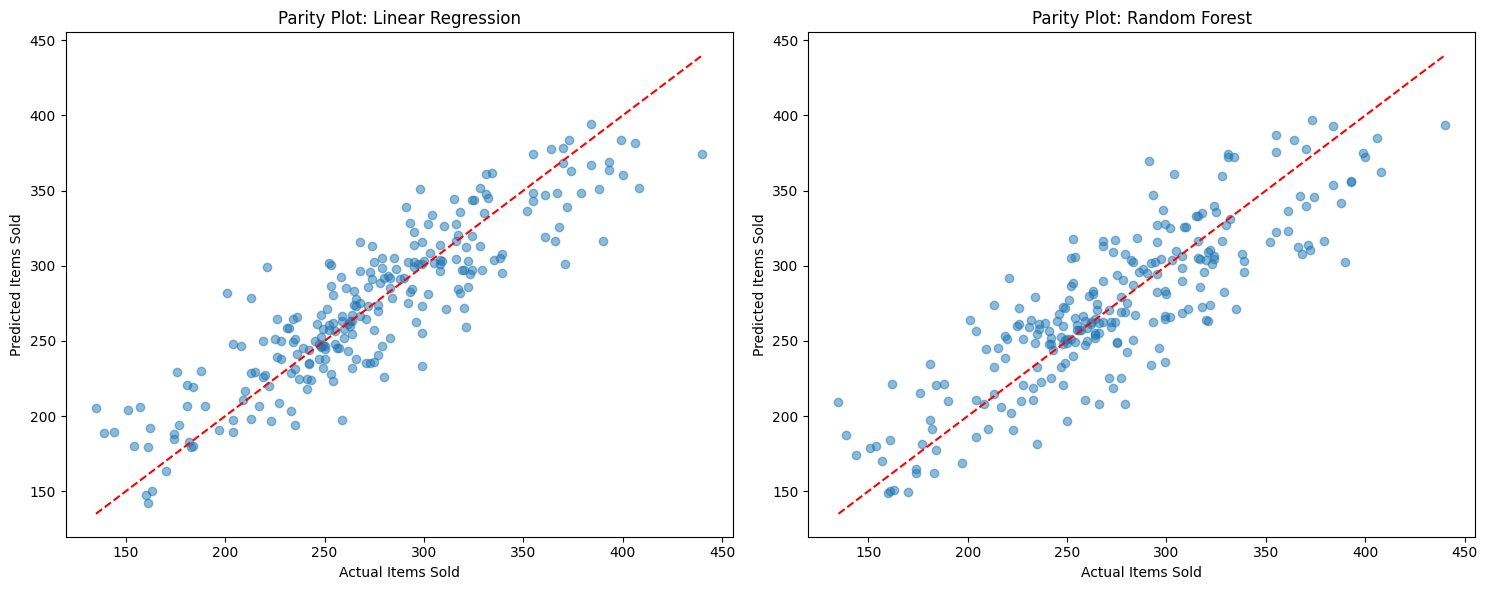

--- Linear Regression ---
RMSE: 27.13
MAE: 21.07
--- Random Forest ---
RMSE: 31.19
MAE: 25.03


In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

plt.figure(figsize=(15, 6))

for i, (name, model) in enumerate(models.items()):
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'MAE': mae}
    
    print(f"--- {name} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    
    # Parity Plot
    plt.subplot(1, 2, i+1)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'Parity Plot: {name}')
    plt.xlabel('Actual Items Sold')
    plt.ylabel('Predicted Items Sold')

plt.tight_layout()
plt.show()

### Feature Importances (Random Forest)

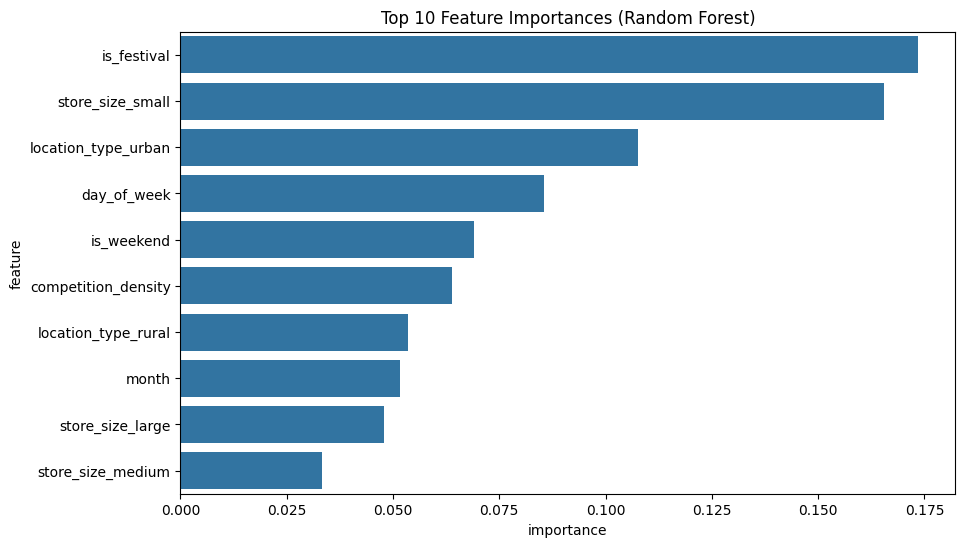

Top 5 Most Influential Features:
                feature  importance
16          is_festival    0.173610
10     store_size_small    0.165463
7   location_type_urban    0.107645
13          day_of_week    0.085597
15           is_weekend    0.069095


In [ ]:
# Get feature names after OHE
ohe_feature_names = pipe.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
all_feature_names = ohe_feature_names + num_features

importances = pipe.named_steps['regressor'].feature_importances_
feat_importance_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances}).sort_values('importance', ascending=False)

print("Top 5 Most Influential Features:")
print(feat_importance_df.head(5))

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_importance_df.head(10))
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()